In [67]:
from pathlib import Path
import asyncio

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [68]:
import os
import numpy as np
import pandas as pd
from scipy import stats


def transform_accelerometer_csv(filepath: str, label: str = None, fs: float = 25.0) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]

    if label is None:
        label = os.path.basename(os.path.dirname(filepath))

    axes = {
        "X": df["accelerometer_X"].values,
        "Y": df["accelerometer_Y"].values,
        "Z": df["accelerometer_Z"].values,
    }

    features = {}

    # ---- Статистичні / часові ознаки по кожній осі ----
    for name, values in axes.items():
        features[f"{name}_mean"] = np.mean(values)
        features[f"{name}_std"] = np.std(values)
        features[f"{name}_min"] = np.min(values)
        features[f"{name}_max"] = np.max(values)
        features[f"{name}_range"] = np.ptp(values)
        features[f"{name}_median"] = np.median(values)
        features[f"{name}_iqr"] = np.percentile(values, 75) - np.percentile(values, 25)
        features[f"{name}_rms"] = np.sqrt(np.mean(values ** 2))
        features[f"{name}_mad"] = np.mean(np.abs(values - np.mean(values)))
        features[f"{name}_skew"] = stats.skew(values)
        features[f"{name}_kurtosis"] = stats.kurtosis(values)
        features[f"{name}_energy"] = np.sum(values ** 2) / len(values)

        # zero crossing rate (відносно середнього)
        centered = values - np.mean(values)
        zcr = np.sum(np.diff(np.sign(centered)) != 0) / len(centered)
        features[f"{name}_zcr"] = zcr

        # jerk (похідна)
        jerk = np.diff(values) * fs
        features[f"{name}_jerk_mean"] = np.mean(jerk)
        features[f"{name}_jerk_std"] = np.std(jerk)

        # кількість піків (простий детектор локальних максимумів)
        peaks = np.sum(
            (values[1:-1] > values[:-2]) & (values[1:-1] > values[2:])
        )
        features[f"{name}_peak_count"] = peaks

    # ---- Signal Magnitude Vector (SMV) ----
    smv = np.sqrt(axes["X"] ** 2 + axes["Y"] ** 2 + axes["Z"] ** 2)
    features["SMV_mean"] = np.mean(smv)
    features["SMV_std"] = np.std(smv)
    features["SMV_max"] = np.max(smv)
    features["SMV_min"] = np.min(smv)

    # Signal Magnitude Area
    features["SMA"] = np.mean(np.abs(axes["X"]) + np.abs(axes["Y"]) + np.abs(axes["Z"]))

    # ---- Кореляції між осями ----
    features["corr_XY"] = np.corrcoef(axes["X"], axes["Y"])[0, 1]
    features["corr_XZ"] = np.corrcoef(axes["X"], axes["Z"])[0, 1]
    features["corr_YZ"] = np.corrcoef(axes["Y"], axes["Z"])[0, 1]

    # ---- Формуємо результат ----
    result = {"class": label, **features}
    return pd.DataFrame([result])

async def transform_accelerometer_csv_async(input_path: Path, class_name: str = None) -> pd.DataFrame:
    return await asyncio.to_thread(transform_accelerometer_csv, input_path, class_name)

In [69]:
async def load_all_data(data_path: Path, classes: list[str]):
    tasks = []
    for cls in classes:
        class_data_path = data_path / cls
        for file in class_data_path.glob('*.csv'):
            tasks.append(transform_accelerometer_csv_async(file.absolute(), cls))

    rows = await asyncio.gather(*tasks)
    return pd.concat(rows, ignore_index=True)

In [70]:
data_path = Path('datasets/accelerometer')
classes = ['idle', 'running', 'stairs', 'walking']

df = await load_all_data(data_path, classes)

In [71]:
df.head()

,class,X_mean,X_std,X_min,X_max,X_range,X_median,X_iqr,X_rms,X_mad,...,Z_jerk_std,Z_peak_count,SMV_mean,SMV_std,SMV_max,SMV_min,SMA,corr_XY,corr_XZ,corr_YZ
0,idle,-0.060813,0.330578,-0.885855,0.828394,1.714249,-0.043095,0.356736,0.336125,0.242357,...,15.983057,10,9.704222,0.260093,10.202839,8.909465,13.911589,-0.132054,0.176976,-0.636990
1,idle,-0.066878,0.361401,-0.885855,0.828394,1.714249,-0.057461,0.360327,0.367537,0.274673,...,15.102617,9,9.774753,0.273026,10.523275,9.296374,14.060509,0.233055,0.232341,-0.626861
2,idle,0.267512,0.069947,0.162806,0.440533,0.277727,0.260968,0.044293,0.276506,0.049395,...,0.680871,9,9.772645,0.021163,9.814973,9.719853,10.078472,-0.053204,-0.063746,0.050189
3,idle,0.264320,0.212522,-0.373495,1.010353,1.383848,0.258574,0.034716,0.339162,0.092640,...,1.029968,9,9.768307,0.026738,9.815488,9.663348,10.175836,0.697684,-0.654687,-0.101484
4,idle,0.301669,0.162091,0.172383,1.010353,0.837970,0.265756,0.050279,0.342458,0.080764,...,0.982309,7,9.763780,0.024665,9.791803,9.663348,10.146627,0.455495,-0.872000,-0.578407


In [72]:
cols_to_convert = df.dtypes[(df.dtypes == 'str')].index
for column in cols_to_convert:
    uniques = df[column].unique().tolist()
    df[column] = df[column].map(lambda x: uniques.index(x))

df.head()

,class,X_mean,X_std,X_min,X_max,X_range,X_median,X_iqr,X_rms,X_mad,...,Z_jerk_std,Z_peak_count,SMV_mean,SMV_std,SMV_max,SMV_min,SMA,corr_XY,corr_XZ,corr_YZ
0,0,-0.060813,0.330578,-0.885855,0.828394,1.714249,-0.043095,0.356736,0.336125,0.242357,...,15.983057,10,9.704222,0.260093,10.202839,8.909465,13.911589,-0.132054,0.176976,-0.636990
1,0,-0.066878,0.361401,-0.885855,0.828394,1.714249,-0.057461,0.360327,0.367537,0.274673,...,15.102617,9,9.774753,0.273026,10.523275,9.296374,14.060509,0.233055,0.232341,-0.626861
2,0,0.267512,0.069947,0.162806,0.440533,0.277727,0.260968,0.044293,0.276506,0.049395,...,0.680871,9,9.772645,0.021163,9.814973,9.719853,10.078472,-0.053204,-0.063746,0.050189
3,0,0.264320,0.212522,-0.373495,1.010353,1.383848,0.258574,0.034716,0.339162,0.092640,...,1.029968,9,9.768307,0.026738,9.815488,9.663348,10.175836,0.697684,-0.654687,-0.101484
4,0,0.301669,0.162091,0.172383,1.010353,0.837970,0.265756,0.050279,0.342458,0.080764,...,0.982309,7,9.763780,0.024665,9.791803,9.663348,10.146627,0.455495,-0.872000,-0.578407


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6462 entries, 0 to 6461
Data columns (total 57 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   class         6462 non-null   int64  
 1   X_mean        6462 non-null   float64
 2   X_std         6462 non-null   float64
 3   X_min         6462 non-null   float64
 4   X_max         6462 non-null   float64
 5   X_range       6462 non-null   float64
 6   X_median      6462 non-null   float64
 7   X_iqr         6462 non-null   float64
 8   X_rms         6462 non-null   float64
 9   X_mad         6462 non-null   float64
 10  X_skew        6462 non-null   float64
 11  X_kurtosis    6462 non-null   float64
 12  X_energy      6462 non-null   float64
 13  X_zcr         6462 non-null   float64
 14  X_jerk_mean   6462 non-null   float64
 15  X_jerk_std    6462 non-null   float64
 16  X_peak_count  6462 non-null   int64  
 17  Y_mean        6462 non-null   float64
 18  Y_std         6462 non-null   float64
 

In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
class,6462.0,1.437326,1.067895,0.000000,1.000000,1.000000,3.000000,3.000000
X_mean,6462.0,1.923550,4.592754,-7.216762,-2.567462,0.524490,6.094720,13.119427
X_std,6462.0,6.047206,3.603417,0.011577,3.492232,6.072508,9.091413,15.722598
X_min,6462.0,-8.995760,6.921241,-39.188293,-12.169727,-7.264008,-4.788403,0.981623
X_max,6462.0,16.152018,13.680749,-0.541090,2.987964,12.133814,28.452694,39.188293
X_range,6462.0,25.147779,14.387720,0.043096,14.786591,26.575639,36.272155,72.367143
X_median,6462.0,1.336733,3.452385,-5.621586,-1.951275,0.462081,4.378995,10.204087
X_iqr,6462.0,7.195191,4.733630,0.013168,3.722385,7.165846,10.760740,23.762452
X_rms,6462.0,7.434691,4.366898,0.091712,4.501822,7.531075,10.953991,19.669309
X_mad,6462.0,4.724854,2.877549,0.009226,2.684320,4.815947,7.100771,12.619039


In [75]:
correlations = df.corrwith(df['class']).drop(['class'])

threshold = 0.5
selected_features = correlations[correlations.abs() > threshold]

print(selected_features)

Y_mean     -0.799178
Y_min      -0.773675
Y_median   -0.799873
Z_mean     -0.753107
Z_min      -0.702447
Z_range     0.596183
Z_median   -0.675353
SMV_min    -0.649346
dtype: float64


In [76]:
df.groupby('class').agg(
    count=pd.NamedAgg(column='class', aggfunc='count'),
)

,count
class,
0,1039
1,3408
2,165
3,1850


In [77]:
X = df.drop(columns=['class']).to_numpy()
Y = df[['class']].to_numpy().T[0]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)

In [78]:
svc_clf = sklearn.svm.SVC().fit(X_train, y_train)
svc_clf

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [79]:
y_pred = svc_clf.predict(X_test)
print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=classes, zero_division=False))

Accuracy Score: 0.9722
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       220
     running       1.00      0.99      1.00       689
      stairs       0.00      0.00      0.00        30
     walking       0.91      1.00      0.95       354

    accuracy                           0.97      1293
   macro avg       0.73      0.75      0.74      1293
weighted avg       0.95      0.97      0.96      1293



<Axes: >

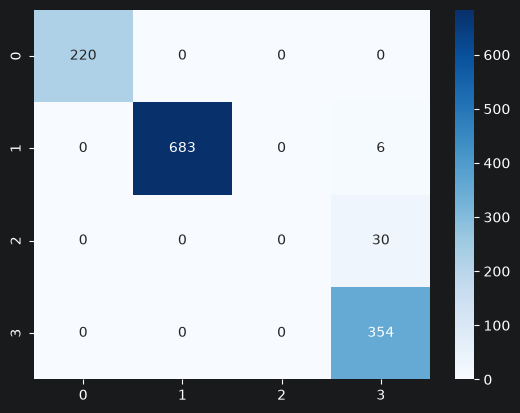

In [80]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [81]:
tree_clf = RandomForestClassifier().fit(X_train, y_train)
tree_clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
y_pred = tree_clf.predict(X_test)
print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=classes, zero_division=False))

Accuracy Score: 0.9992
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       220
     running       1.00      1.00      1.00       689
      stairs       1.00      0.97      0.98        30
     walking       1.00      1.00      1.00       354

    accuracy                           1.00      1293
   macro avg       1.00      0.99      1.00      1293
weighted avg       1.00      1.00      1.00      1293



<Axes: >

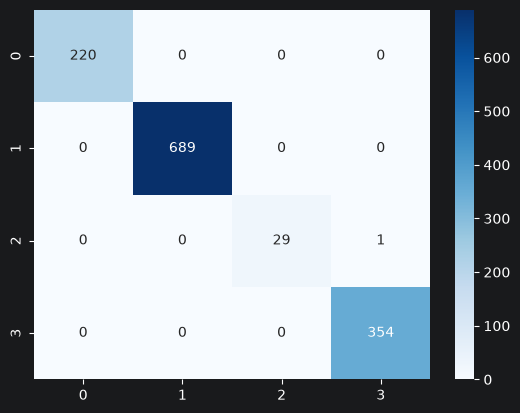

In [83]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

## Висновок

З проведених досліджень, можемо зробити висновок, що обидві створені моделі мають високу якість (svc model accuracy score = 0.9722, tree model accuracy score = 0.9992).

Проте модель побудована на *SupportVectorClassifier*, показала повністю провальні результати при класифікації `stairs` кейсів, при збереженні якості класифікації (precision, recall метрики) `idle`, `running` кейсів та невеличкою просадкою класифікації `walking` (метрика precision). Проаналізувши Confusion Matrix, можемо бачити, що усі кейси `stairs` (30) та декілька кейсів `running` (6) були класифіковані як `walking`, про що і каже `precision` метрика.

На відміну від моделі побудованої на *SupportVectorClassifier*, модель побудована на *RandomForestClassifier* показала ідеальні результати